# SimPy and simpy_helpers:  In Class Exercise

###  Bus 36109 "Advanced Decision Modeling with Python", Don Eisenstein
Don Eisenstein &copy; Copyright 2026, University of Chicago 

---

#### Instructions
- Customers arrive according to an exponential distribution with mean time between arrivals of 30 seconds
- Customers will wait, if necessary, in a single queue for one of two parallel servers 
- Service times for each server is uniformly distributed between 20 and 80 seconds 
- Simulate 5000 customers though the system  
- Set your seed to 721
- Output:
    - The Average waiting time for customers 
        - Your answer should be around 71 secs
    - The Average utilization of the servers
        - Your answer should be around 0.84
    - The Average number of customers in service
        - Your answer should be around 1.68
    - Plot the queue size over time
    - The Average wait time for customers that enter the system between time 90,000 seconds and 110,000 seconds into the simulation.
        - Your answer should be around 47.84

In [146]:
import numpy as np
import simpy
from numpy import mean
from simpy_helpers import Entity, Resource, Source, Stats

In [147]:
class Customer(Entity):
    def process(self):
        yield self.wait_for_resource(system_server)
        yield self.process_at_resource(system_server)
        self.release_resource(system_server)

In [148]:
class CustomerServer(Resource):
    def service_time(self):
        return np.random.uniform(low=20.0, high=80.0, size=None)

In [149]:
class CustomerSource(Source):
    def interarrival_time(self):
        return np.random.exponential(30) # seconds
    def build_entity(self):
        attributes = {'arrival_time': self.now()}
        return Customer(env, attributes)

In [161]:
np.random.seed(721)

env = simpy.Environment()
system_server = CustomerServer(env, capacity=2)
system_source = CustomerSource(env, number=5000)

In [162]:
env.process(system_source.start(debug=False))
env.run()

In [169]:
# Average waiting time
waiting_times = Stats.get_waiting_times(system_server)
average_waiting_time = round(mean(waiting_times), 2)
print(f'Average customer waits for {average_waiting_time} seconds')

# Utilization
utilization = Stats.utilization_over_time(system_server)
average_utilization = round(mean(utilization), 2)
print(f'Average utilization is {average_utilization}')

# Number of customer in service
server_inventory = Stats.number_being_processed_over_time(system_server)
average_server_inventory = round(mean(server_inventory), 2)
print(f'On average, {average_server_inventory} customers are in service')

# Queue size
queue_size = Stats.queue_size_over_time(system_server)
average_queue_size = round(mean(queue_size), 2)
print(f'On average, {average_queue_size} customers are in the queue')

# The average wait time for customers that enter the system between time 90,000 seconds and 110,000 seconds into the simulation.
entities = Stats.get_entities()
cohort_90k_110k = []
cohort_wait_time = []

for entity in entities:
    if 90000 <= entity.attributes['arrival_time'] <= 110000:
        cohort_90k_110k.append(entity)

for cust in cohort_90k_110k:
    cohort_wait_time.append(cust.get_total_waiting_time())

average_cohort_wait_time = round(mean(cohort_wait_time), 2)
print(f'The cohort_90k_110k\'s average wait time is {average_cohort_wait_time} seconds')

Average customer waits for 71.83 seconds
Average utilization is 0.84
On average, 1.68 customers are in service
On average, 2.42 customers are in the queue
The cohort_90k_110k's average wait time is 47.85 seconds


In [170]:
import matplotlib.pyplot as plt

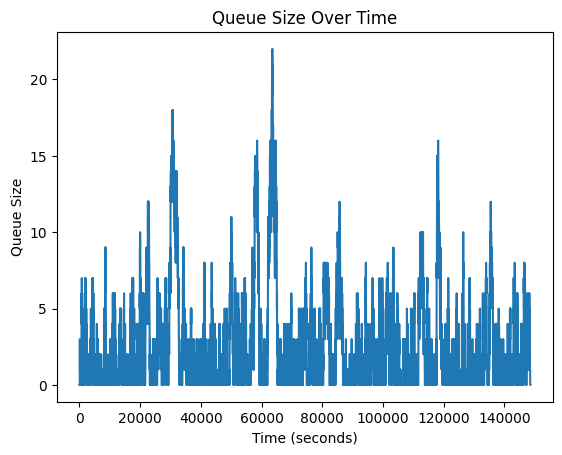

In [171]:
plt.plot(queue_size)
plt.xlabel("Time (seconds)")
plt.ylabel("Queue Size")
plt.title("Queue Size Over Time")
plt.show()